In [1]:
preset_parameters = {'fftsize': 1024, 'overlap': 0.95, 'integration': 5, 'fmin': 24.5, 'fmax': 26.5, 'peak_boundaries': [62, 72], 'valley_boundaries': [52, 82], 'species_id': 'abw'}

In [2]:
from lib.networkFuntions import get_network_details

net = 'YV'
sta = 'RR29'
cha = 'BDH.D'

# Load station details for the considered network
dfstations = get_network_details(net, '/Volumes/SDS/INVENTORIES')

print(dfstations.head())



  net  net_start             net_end   sta      lon      lat     ele  cha  \
0  YV 2011-01-01 2016-12-31 23:59:59  RR01  55.4230 -20.0069 -4298.0  BHZ   
1  YV 2011-01-01 2016-12-31 23:59:59  RR01  55.4230 -20.0069 -4298.0  BDH   
2  YV 2011-01-01 2016-12-31 23:59:59  RR01  55.4230 -20.0069 -4298.0  BH2   
3  YV 2011-01-01 2016-12-31 23:59:59  RR01  55.4230 -20.0069 -4298.0  BH1   
4  YV 2011-01-01 2016-12-31 23:59:59  RR02  54.4984 -20.3392 -4436.0  BHZ   

   sample_rate  sensitivity           starttime             endtime  
0         50.0  739666000.0 2012-10-05 04:53:07 2013-11-07 00:08:27  
1         50.0       2008.5 2012-10-05 04:53:07 2013-11-07 00:08:27  
2         50.0  742653000.0 2012-10-05 04:53:07 2013-11-07 00:08:27  
3         50.0  753854000.0 2012-10-05 04:53:07 2013-11-07 00:08:27  
4         50.0  745640000.0 2012-10-03 15:34:32 2012-10-05 21:30:27  


In [3]:
from lib.networkFuntions import get_network_file_list

# Get the list of files for the considered network and station
dfmseeds = get_network_file_list(net, sta, './data/SDS')
print(dfmseeds.head())

                                            filename  year net   sta    cha  \
0  data/SDS/2013/YV/RR29/BDH.D/YV.RR29.00.BDH.D.2...  2013  YV  RR29  BDH.D   
1  data/SDS/2013/YV/RR29/BDH.D/YV.RR29.00.BDH.D.2...  2013  YV  RR29  BDH.D   
2  data/SDS/2013/YV/RR29/BDH.D/YV.RR29.00.BDH.D.2...  2013  YV  RR29  BDH.D   
3  data/SDS/2013/YV/RR29/BDH.D/YV.RR29.00.BDH.D.2...  2013  YV  RR29  BDH.D   
4  data/SDS/2013/YV/RR29/BDH.D/YV.RR29.00.BDH.D.2...  2013  YV  RR29  BDH.D   

  julian  starttime   datetime  
0    152 2013-06-01 2013-06-01  
1    153 2013-06-02 2013-06-02  
2    154 2013-06-03 2013-06-03  
3    155 2013-06-04 2013-06-04  
4    156 2013-06-05 2013-06-05  


In [4]:
from datetime import datetime

# Define the time window for which you want to process the data
dt1, dt2 = datetime(2013,6,1), datetime(2013,7,1)

In [5]:
from lib.networkFuntions import get_stream_for_selected_file
from lib.signalProcessing import get_spectrogram, get_cepstro
import pandas as pd 
import numpy as np 

# Initialize empty lists to store concatenated results
all_frequencies = []
all_times = []
all_spectrograms = []


# Compute the longterm cepstrogram on a daily basis and concatenate the results
for d in pd.date_range(dt1, dt2, freq='D'):
    file = dfmseeds[(dfmseeds['starttime'] == d) & (dfmseeds['cha'] == cha)].iloc[0].filename

    # get the stream containing the data
    stream = get_stream_for_selected_file(file)
    
    # get the hydrophone trace only
    tr = stream.select(channel='*H')[0]

    # Compute the spectrogram for the trace and store the results
    f, t, s = get_spectrogram(
        tr,
        preset_parameters['fftsize'],
        int(preset_parameters['fftsize'] * preset_parameters['overlap']),
        preset_parameters['integration'],
        [preset_parameters['fmin'], preset_parameters['fmax']]
    )

    all_frequencies.append(f)
    all_times.append(t)
    all_spectrograms.append(s)

    # Concatenate all results
    f = all_frequencies[0]  # Frequencies are the same for all traces
    t = np.concatenate(all_times)
    s = np.concatenate(all_spectrograms, axis=1)

# Compute the cepstrogram for the concatenated spectrogram
t,q,c = get_cepstro(t, f, s) 



In [6]:
from lib.whaleIciDetection import get_mean_cepstrum
from datetime import timedelta

# to adapt to the metric DPH, we compute the mean cepstrum on an hourly basis and concatenate the results

t_hourly, c_hourly = [], []


delta = timedelta(seconds=3600)
for hour in pd.date_range(start=dt1, end=dt2, freq='H'):

    mask = (t >= hour) & (t < hour + delta)
    if np.any(mask):
        c_hour = get_mean_cepstrum(c[:, mask], q)
        t_hourly.append(hour)
        c_hourly.append(c_hour)
c_hourly = np.transpose(c_hourly)

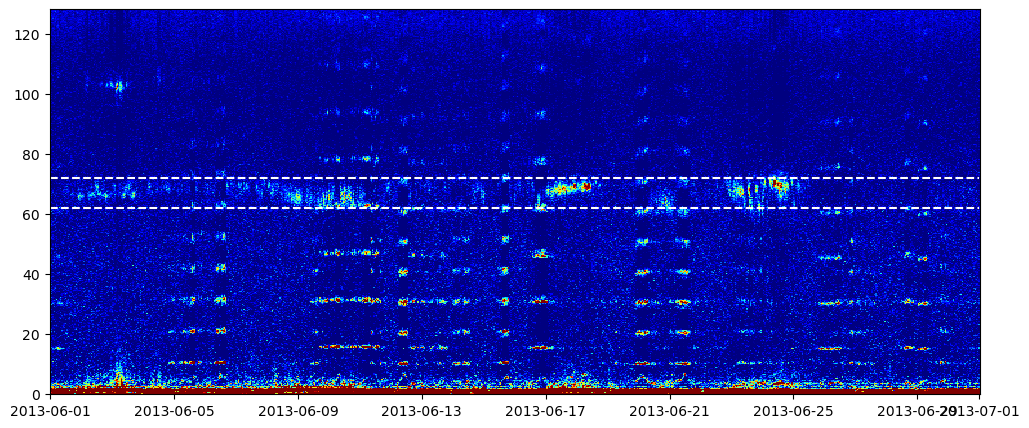

In [7]:
import matplotlib.pyplot as plt

# plot the cepstrogram
plt.figure(figsize=(12, 5))
plt.pcolormesh(t_hourly,q,c_hourly, vmin=0, vmax=0.02, cmap='jet')
plt.plot([dt1, dt2], [62,62], 'w--')
plt.plot([dt1, dt2], [72,72], 'w--')
plt.show()

In [8]:
from lib.whaleIciDetection import get_peak_to_valley_ratio

# compute the peak to valley ratio for the mean cepstrum 
p2vr= get_peak_to_valley_ratio(q, c_hourly, preset_parameters['peak_boundaries'], preset_parameters['valley_boundaries'], 12)


# apply a threshold to the peak to valley ratio to detect positive detections
threshold = 0.5
above_threshold_indices = np.where(p2vr > threshold)[0]

positive_detection = np.zeros_like(p2vr, dtype=int)
positive_detection[above_threshold_indices] = 1 




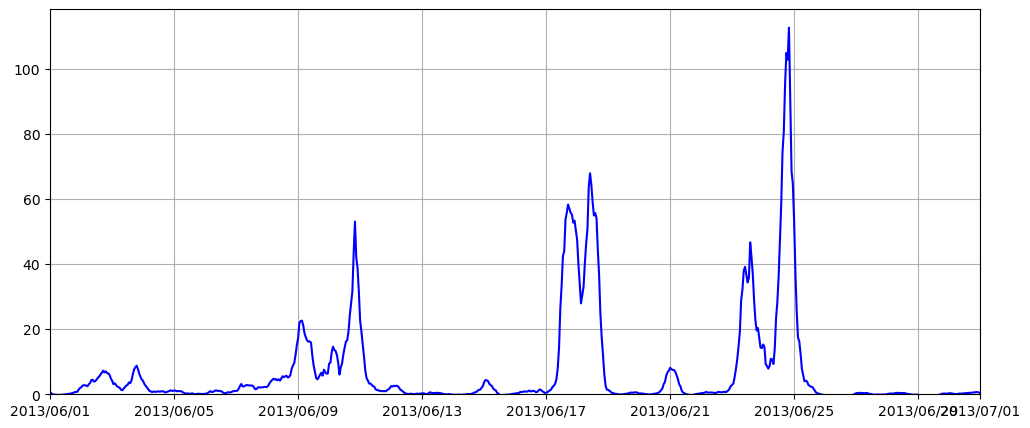

In [14]:
# plot the peak to valley ratio

plt.figure(figsize=(12, 5))
ax=plt.subplot()
ax.plot(t_hourly, p2vr, color='blue', label='p2vr')
ax.grid()
ax.set_ylim(0,)
ax.set_xlim(dt1,dt2)

ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y/%m/%d'))
plt.show()

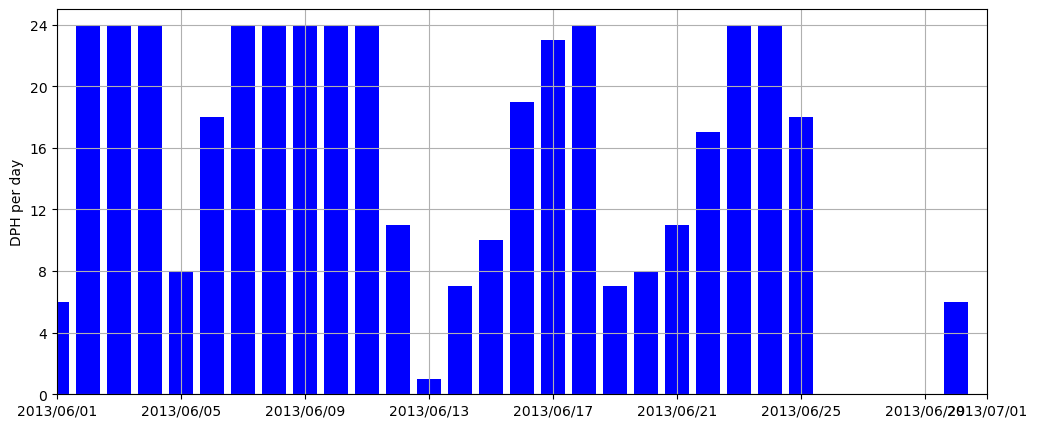

In [12]:
# compute the DPH per day by resampling the positive detections on an hourly basis and summing them up on a daily basis

resampled_positive = pd.Series(positive_detection).groupby(pd.to_datetime(t_hourly).floor("1H")).sum()

daily_positive_hours = resampled_positive.groupby(resampled_positive.index.date).sum()
 

# plot the DPH per day
plt.figure(figsize=(12, 5))
ax3 = plt.subplot(1, 1, 1)
ax3.bar(daily_positive_hours.index, daily_positive_hours.values, color='blue')
ax3.set_ylim(0,25)
ax3.set_yticks(range(0, 25, 4))
ax3.set_xlim(dt1,dt2)
ax3.grid()
ax3.set_ylabel('DPH per day')
ax3.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y/%m/%d'))
plt.show()

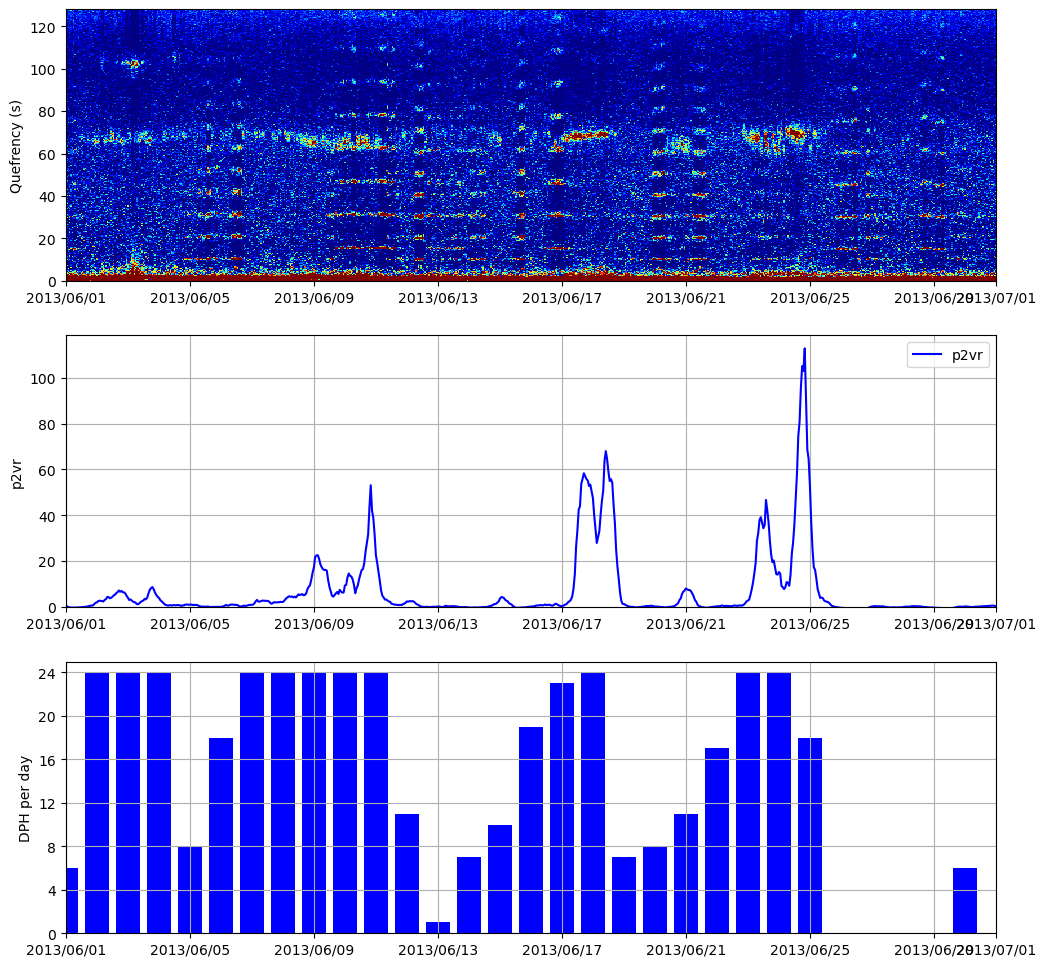

In [13]:
plt.figure(figsize=(12, 12))
ax1 = plt.subplot(3, 1, 1)
ax1.pcolormesh(t_hourly,q,c_hourly, vmin=0, vmax=0.01, cmap='jet')
ax1.set_xlim(dt1,dt2)
ax1.set_ylabel('Quefrency (s)')
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y/%m/%d'))

ax2 = plt.subplot(3, 1, 2)
ax2.plot(t_hourly, p2vr, color='blue', label='p2vr')
ax2.grid()
ax2.set_ylim(0,)
ax2.set_xlim(dt1,dt2)
ax2.set_ylabel('p2vr')
ax2.legend()
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y/%m/%d'))

ax3 = plt.subplot(3, 1, 3)
ax3.bar(daily_positive_hours.index, daily_positive_hours.values, color='blue')
ax3.set_ylim(0,25)
ax3.set_yticks(range(0, 25, 4))
ax3.set_xlim(dt1,dt2)
ax3.grid()
ax3.set_ylabel('DPH per day')
ax3.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y/%m/%d'))


plt.show()